# Crossreads Petrography: pXRF Processing

In [1]:
import sys; sys.path.append('..')
from crossreads_petrography.pxrf import *

In [2]:
xrf = PXRFConverter()
xrf

Initializing PXRFConverter @ 2024-08-23 14:31:09,035


## Descriptions

This file lives on Google Drive on the Crossreads team drive. It contains notes about the samples, including the Isic codes.

In [3]:
pd.options.display.max_columns = 1000
xrf.df_descriptions

Loading pXRF descriptions @ 2024-08-23 14:31:09,042
Authenticating and accessing Google Spreadsheet @ 2024-08-23 14:31:09,042
Reading data from spreadsheet worksheet 0 @ 2024-08-23 14:31:09,998
Read 602 rows from spreadsheet @ 2024-08-23 14:31:10,449


,instrument,site,day,month,year,cass,inv/id,Isic,count analyses,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z,1,2,3,4
1,demo-MK,salinas,,10,2022,museo,,Isic000004,6,"wh, between r n, L 1","wh, between f g, L 1","wh, end of L 3, diagonal","gr, x e, L 2","gr, inside first m of m m, L 1","between fe c, L 4",,,,,,,,,,,,,,,,,,,,,"wh, between r n, L 1","wh, between f g, L 1","wh, end of L 3, diagonal","gr, x e, L 2"
2,demo-MK,termini imerese,,3,2023,depositi,,Isic000086,9,"yellow, v","yellow, back","yellow, back","pink, back","pink, back","pink, below I","rosso, edge","rosso, back, edge","rosso, vein",,,,,,,,,,,,,,,,,,"yellow, v","yellow, back","yellow, back","pink, back"
3,demo-MK,termini imerese,,3,2023,museo,,Isic000092,6,"O, L 1","Q, L 1","O, L 1",sample,sample,sample,,,,,,,,,,,,,,,,,,,,,"O, L 1","Q, L 1","O, L 1",sample
4,demo-MK,termini imerese,,3,2023,museo,,Isic000095,15,yellow,yellow,yellow,orange below GIO,orange below GIO,orange o in PO,dark pink vein,dark pink vein,"dark pink vein, right side","pink, above NP","pink, centre frame","pink, above EN","red, sample","red, sample","red, sample",,,,,,,,,,,,yellow,yellow,yellow,orange below GIO
5,demo-MK,termini imerese,,3,2023,museo,,Isic000097,3,"above roc, L 5","between iv praef, L 6","E, L 5",,,,,,,,,,,,,,,,,,,,,,,,"above roc, L 5","between iv praef, L 6","E, L 5",
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,demo-MK,taormina,22,1,2024,,torso,taorminatorso,4,under right armpit,left shoulder,right shoulder,"brown, hair",,,,,,,,,,,,,,,,,,,,,,,under right armpit,left shoulder,right shoulder,"brown, hair"
599,demo-MK,tindari,,7,2024,,TIND004,tindariTIND004,4,white,white,grey,grey,,,,,,,,,,,,,,,,,,,,,,,white,white,grey,grey
600,demo-MK,tindari,,7,2024,,TIND005,tindariTIND005,3,sample,sample,sample,,,,,,,,,,,,,,,,,,,,,,,,sample,sample,sample,
601,demo-MK,tindari,,7,2024,,TIND007,tindariTIND007,3,sample,sample,sample,,,,,,,,,,,,,,,,,,,,,,,,sample,sample,sample,


## Standards



In [4]:
xrf.df_standards

Loading pXRF standard values @ 2024-08-23 14:31:10,474
Authenticating and accessing Google Spreadsheet @ 2024-08-23 14:31:10,475
Reading data from spreadsheet worksheet 0 @ 2024-08-23 14:31:11,420
Read 11 rows from spreadsheet @ 2024-08-23 14:31:12,795


,0CC,10CC,20CC,30CC,40CC,50CC,60CC,70CC,80CC,90CC,100CC
Element,,,,,,,,,,,
SiO2,91.04,84.72,78.82,73.80,64.45,55.45,32.57,27.17,21.53,11.57,0.00
K2O,6.00,5.59,5.20,4.87,4.25,3.66,2.15,1.79,1.42,0.76,0.00
CaO,0.96,7.88,14.34,19.82,30.01,39.80,64.64,70.49,76.59,87.37,99.87
Fe2O3,2.00,1.81,1.65,1.52,1.29,1.09,0.64,0.55,0.46,0.30,0.13
Ba,120,108,97,89,74,61,33,27,21,11,0
Ce,195,175,158,144,120,99,53,43,33,17,0
Co,4,4,3,3,2,2,1,1,1,0,0
Cr,12,11,10,9,7,6,3,3,2,1,0
Fe,14261,12890,11693,10732,9069,7605,4374,3698,3024,1902,700


## pXRF input data

Two kinds of files:
* "MK" files
    * Filename must start with 
    * Only Si, K, Ca, and Fe are included
* "t" files
    * Filenames must start with "t"
    * All elements with linear correlation with standard values (plus HG) are included

pXRF input data is processed in `df_measurements_with_standard_values`, attaching relevant standard values if present from `df_standards`.

In [5]:
xrf.df_measurements_with_standard_values

Parsing pXRF standards data @ 2024-08-23 14:31:12,808
Reading txt data from /Users/ryan/crossreads_petrography_data/data/input/pXRF @ 2024-08-23 14:31:12,810


,Group,Fit_Area,Sigma_Area,Mass_fraction,standard_val,standard_key,source_name,filename,standard_group
Element,,,,,,,,,
Ba,NaN,NaN,NaN,NaN,108.00,10CC,10-1,MK taormina.txt,(all)
CaO,K,1.411975e+05,4.09e+02,0.071200,7.88,10CC,10-1,MK taormina.txt,10-50
Ce,NaN,NaN,NaN,NaN,175.00,10CC,10-1,MK taormina.txt,(all)
Co,NaN,NaN,NaN,NaN,4.00,10CC,10-1,MK taormina.txt,(all)
Cr,NaN,NaN,NaN,NaN,11.00,10CC,10-1,MK taormina.txt,(all)
...,...,...,...,...,...,...,...,...,...
Ti,K,2.741946e+01,2.99e+01,0.000027,27.00,100CC,t0-100CC-3,t termini.txt,(all)
V,NaN,NaN,NaN,NaN,0.00,100CC,t0-100CC-3,t termini.txt,(all)
Y,K,5.072686e+02,8.10e+01,0.000067,0.00,100CC,t0-100CC-3,t termini.txt,(all)


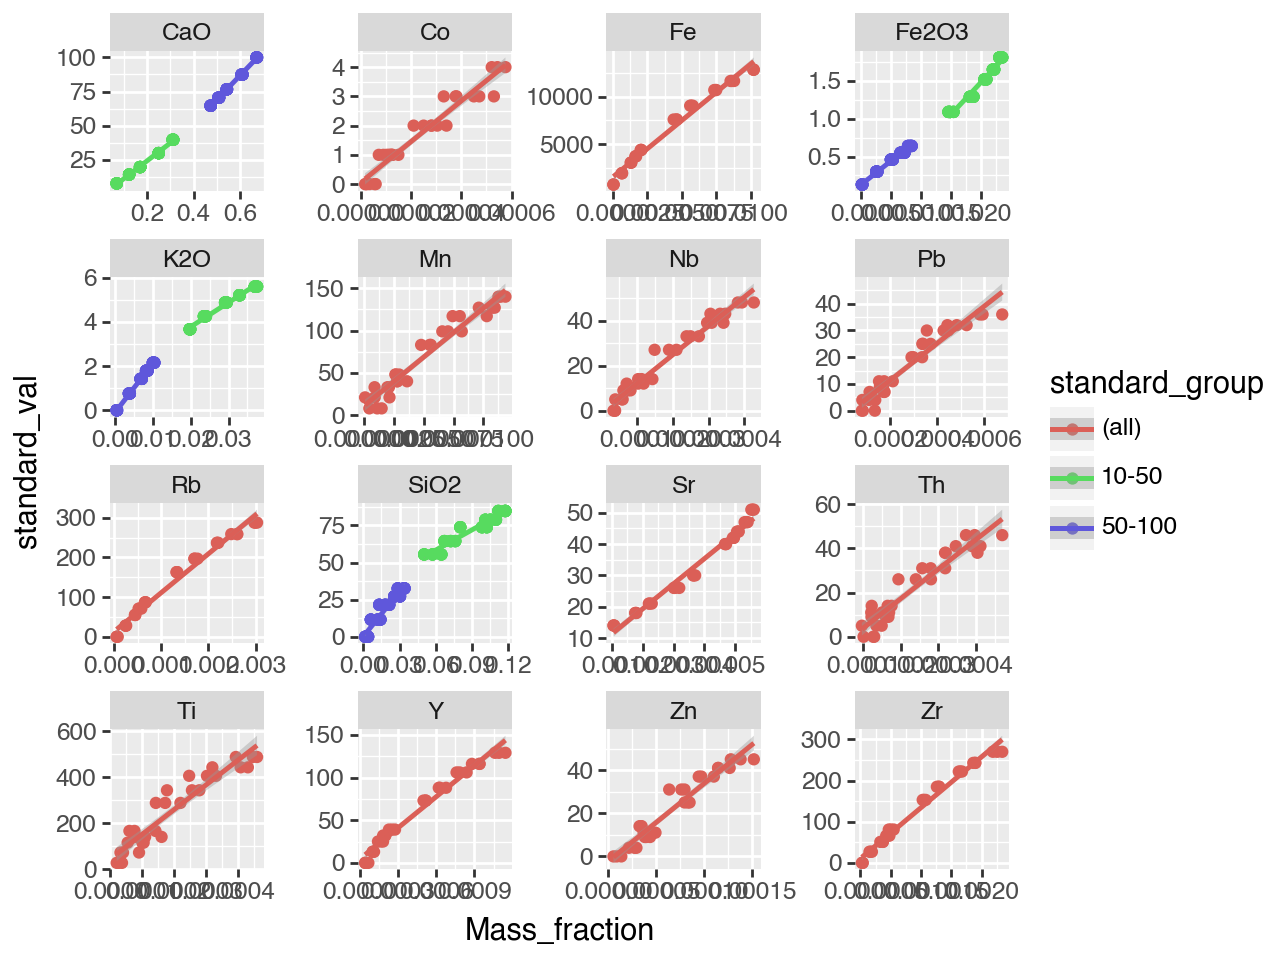

In [11]:
# Plotting mass fraction against standard values to find slope and intercept
xrf.plot()

In [12]:
# Finding mass fraction against standard values to find slope and intercept
# we add Hg to the list of elements by copying the slope and intercept from Pb
df=xrf.df_linreg
df

,Element,standard_group,m,q
0,CaO,10-50,1.310244e+02,-1.952841
1,CaO,50-100,1.777207e+02,-19.755472
2,Co,(all),6.959382e+04,0.060214
3,Fe,(all),1.200097e+06,1511.973089
4,Fe2O3,10-50,8.505612e+01,-0.221921
5,Fe2O3,50-100,6.322687e+01,0.122334
6,K2O,10-50,1.098701e+02,1.573472
7,K2O,50-100,2.224365e+02,-0.105489
8,Mn,(all),1.150827e+06,11.149036
9,Nb,(all),1.281943e+05,-0.852171


In [15]:
# Measurements with adjusted mass fraction values due to slope and intercept from regression
xrf.df_adjusted

Group    Fit_Area  Sigma_Area  Mass_fraction  \
source_name          Element                                                
capitellogrigio-MK-a SiO2        K       98.69        48.6           0.01   
                     K2O         K      861.56       115.0           0.00   
                     CaO         K  1080698.00      1060.0           0.47   
                     Fe2O3       K     5020.21       122.0           0.00   
capitellogrigio-MK-b SiO2        K        0.04        49.2           0.00   
...                            ...         ...         ...            ...   
ISic003083-t-c       Zr          K      236.76        93.5           0.00   
                     Nb          K      221.03        84.1           0.00   
                     Hg          L      241.08        53.3           0.00   
                     Pb          L     1115.42        69.7           0.00   
                     Th          L      813.84       106.0           0.00   

                             standard_group          m      q      y  \
source_name          Element                                           
capitellogrigio-MK-a SiO2            50-100    1012.01   0.26   5.66   
                     K2O             50-100     222.44  -0.11  -0.02   
                     CaO             50-100     177.72 -19.76  63.84   
                     Fe2O3           50-100      63.23   0.12   0.20   
capitellogrigio-MK-b SiO2            50-100    1012.01   0.26   0.26   
...                                     ...        ...    ...    ...   
ISic003083-t-c       Zr               (all)  123444.05  10.61  14.38   
                     Nb               (all)  128194.29  -0.85   2.73   
                     Hg               (all)   69419.91  -2.50   2.42   
                     Pb               (all)   69419.91  -2.50  17.32   
                     Th               (all)  133580.29  -9.46   9.67   

                              Calc_fraction desc  
source_name          Element                      
capitellogrigio-MK-a SiO2              8.12       
                     K2O               0.00       
                     CaO              91.62       
                     Fe2O3             0.29       
capitellogrigio-MK-b SiO2              0.42       
...                                     ...  ...  
ISic003083-t-c       Zr               14.38   pi  
                     Nb                2.73   pi  
                     Hg                2.42   pi  
                     Pb               17.32   pi  
                     Th                9.67   pi  

[5929 rows x 10 columns]

In [17]:
xrf.df_adjusted.reset_index().Element.value_counts()

Element
SiO2     556
CaO      556
Fe2O3    556
K2O      556
Sr       285
Pb       285
Hg       285
Nb       285
Zr       285
Y        285
Zn       285
Rb       285
Co       285
Fe       285
Mn       285
Ti       285
Th       285
Name: count, dtype: int64

In [9]:
xrf.df_adjusted.query('Element=="Hg"').sort_values('Mass_fraction')

,,Group,Fit_Area,Sigma_Area,Mass_fraction,standard_group,m,q,y,Calc_fraction,desc
source_name,Element,,,,,,,,,,
cass27-ISic000368-1t,Hg,L,812.57,74.2,0.00,(all),69419.91,-2.5,14.15,14.15,right to dms
ISic000184-t-d,Hg,L,323.98,53.1,0.00,(all),69419.91,-2.5,4.11,4.11,"before L 2, v"
ISic000184-t-e,Hg,L,228.74,54.2,0.00,(all),69419.91,-2.5,2.23,2.23,"v, between I L"
ISic000184-t-f,Hg,L,313.34,53.7,0.00,(all),69419.91,-2.5,3.93,3.93,"v, between I VS"
ISic000191-t-a,Hg,L,366.28,57.3,0.00,(all),69419.91,-2.5,5.07,5.07,"red, N"
...,...,...,...,...,...,...,...,...,...,...,...
EPICUM1-ISic001299-2t,Hg,L,141952.00,421.0,0.04,(all),69419.91,-2.5,2840.94,2840.94,"red, sigma"
t-MARPO-orsi262-a,Hg,L,147674.10,422.0,0.05,(all),69419.91,-2.5,3192.90,3192.90,
EPICUM1-ISic003300-4t,Hg,L,221457.80,523.0,0.06,(all),69419.91,-2.5,4461.20,4461.20,"red, A; interline 1 2, left"


In [10]:
xrf.run()

Processing pXRF data @ 2024-08-23 14:31:17,078
Saving pXRF processed data @ 2024-08-23 14:31:17,078
Saved: pXRF_calculated_fractions.xlsx @ 2024-08-23 14:31:19,115
